In [1]:
import pandas as pd

In [3]:
df  = pd.read_csv("/content/opcode_truncate_dataset.csv")
df.tail(5)

,file_name,family,apk_size,permission_count,api_count,opcode_count,intent_count,PERM,API,INTENT,OPCODE
5002,90f7482ad7ffcc200dfdb444ba539daeea55342e5f299d...,Adware,168493,11.0,188.0,16203.0,1.0,SEND_SMS READ_CONTACTS MODIFY_PHONE_STATE INTE...,u getAnimationList2 access$200 getPoints o isV...,android.intent.action.PHONE_STATE,const/4 const/4 invoke-direct const-string ipu...
5003,1f7c59312e2925ddc19a91f5e9684ec347177d98db32a2...,Adware,647186,6.0,269.0,17538.0,0.0,INTERNET READ_EXTERNAL_STORAGE ACCESS_NETWORK_...,equals setFlag getTitle2 onProgressUpdate acce...,NaN,invoke-direct return-void invoke-direct return...
5004,717aea92b781b76396f45f345752ff82c62ebfce78f18f...,Adware,3582268,40.0,4.0,304.0,28.0,CHANGE_CONFIGURATION DISABLE_KEYGUARD INTERNET...,a b attachBaseContext <init>,com.silib.basic android.intent.action.DOWNLOAD...,invoke-direct return-void invoke-static move-r...
5005,8a5eaa7b90c396dc61545b6ce6cb4f9e328c27b8f3d71e...,Adware,715207,10.0,170.0,37766.0,8.0,SYSTEM_ALERT_WINDOW INTERNET WAKE_LOCK ACCESS_...,equals u onBackPressed getItemId setScrollStat...,android.intent.action.PACKAGE_ADDED android.in...,sget const/16 if-lt new-instance invoke-direct...
5006,4ce2c46fd9d88b2a2552eda6f4afc4c7e19043909fd92a...,Adware,3582950,40.0,4.0,304.0,28.0,CHANGE_CONFIGURATION DISABLE_KEYGUARD INTERNET...,a b attachBaseContext <init>,com.silib.basic android.intent.action.DOWNLOAD...,invoke-direct return-void invoke-static move-r...


In [4]:
df['family'].isnull().sum()

np.int64(9)

In [5]:
df.shape

(5007, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5007 entries, 0 to 5006
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   file_name         5007 non-null   object 
 1   family            4998 non-null   object 
 2   apk_size          5000 non-null   object 
 3   permission_count  4990 non-null   float64
 4   api_count         4990 non-null   float64
 5   opcode_count      4990 non-null   float64
 6   intent_count      4990 non-null   float64
 7   PERM              4974 non-null   object 
 8   API               4961 non-null   object 
 9   INTENT            3867 non-null   object 
 10  OPCODE            4961 non-null   object 
dtypes: float64(4), object(7)
memory usage: 430.4+ KB


In [7]:
df.isnull().sum()

,0
file_name,0
family,9
apk_size,7
permission_count,17
api_count,17
opcode_count,17
intent_count,17
PERM,33
API,46
INTENT,1140


In [8]:
len(df['family'].unique())

14

In [9]:
families_to_exclude = ['Banking', 'Riskware', 'SMS', 'Adware', 'Benign3']
other_families_count = df[~df['family'].isin(families_to_exclude) & df['family'].notna()].shape[0]
print(f"Count of families different from the specified list: {other_families_count}")

Count of families different from the specified list: 8


In [10]:
families_to_exclude = ['Banking', 'Riskware', 'SMS', 'Adware', 'Benign3']
other_families = df[~df['family'].isin(families_to_exclude) & df['family'].notna()]['family'].unique()
print(other_families)

['android.provider.Telephony.SMS_RECEIVED'
 'com.google.android.c2dm.intent.RECEIVE com.google.android.c2dm.intent.RECEIVE net.peakgames.Yuzbir.AUTO_CAMPAIGN_ACTION net.peakgames.Yuzbir.TIME_BONUS_ACTION'
 'com.google.android.gms.measurement.UPLOAD com.google.android.c2dm.intent.RECEIVE com.google.android.c2dm.intent.REGISTRATION'
 'android.appwidget.action.APPWIDGET_UPDATE android.appwidget.action.APPWIDGET_DELETED android.appwidget.action.APPWIDGET_ENABLED android.appwidget.action.APPWIDGET_DISABLED com.android.vending.INSTALL_REFERRER com.google.android.c2dm.intent.RECEIVE com.google.android.gms.measurement.UPLOAD'
 'android.appwidget.action.APPWIDGET_UPDATE android.appwidget.action.APPWIDGET_UPDATE com.google.android.gms.measurement.UPLOAD com.google.android.c2dm.intent.RECEIVE com.google.android.c2dm.intent.REGISTRATION'
 'com.google.android.c2dm.intent.RECEIVE com.google.android.c2dm.intent.REGISTRATION com.jamplay.jamplaymobile.android.intent.APPBOY_PUSH_RECEIVED com.jamplay.jam

In [11]:
families_to_exclude = ['Banking', 'Riskware', 'SMS', 'Adware', 'Benign3']
other_families_df = df[~df['family'].isin(families_to_exclude) & df['family'].notna()]
display(other_families_df)

,file_name,family,apk_size,permission_count,api_count,opcode_count,intent_count,PERM,API,INTENT,OPCODE
1349,pup getDeltaY onLoadCanceled newPaint findFile...,android.provider.Telephony.SMS_RECEIVED,invoke-direct return-void const/4 return const...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3466,etOnScreenKeyboardVisible putEncryptedString c...,com.google.android.c2dm.intent.RECEIVE com.goo...,invoke-direct return-void sget const/16 if-lt ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3503,etAutoZoomEnabled F getCurrentContentInsetRigh...,com.google.android.gms.measurement.UPLOAD com....,const/4 const/16 new-array fill-array-data spu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3824,eInsetLeft runNextNotificationTask buildUpon v...,android.appwidget.action.APPWIDGET_UPDATE andr...,invoke-direct return-void invoke-direct return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3842,alues getVerticalDirection readMultiPolygon re...,android.appwidget.action.APPWIDGET_UPDATE andr...,invoke-direct return-void invoke-direct return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4038,ck readingDone zzaph getWeekForDate setShadowR...,com.google.android.c2dm.intent.RECEIVE com.goo...,sget const/16 if-lt new-instance invoke-direct...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4166,imeForCurrentPosition getPadBottom getCipherSu...,com.inmobi.share.id android.net.conn.CONNECTIV...,invoke-direct return-void invoke-direct return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4224,isfied$11807e61 performIntercept runExec v q a...,android.intent.action.BOOT_COMPLETED android.n...,invoke-direct return-void monitor-enter iget-o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Removing the identified rows

In [12]:
print(f"Shape of DataFrame before removal: {df.shape}")

families_to_exclude = ['Banking', 'Riskware', 'SMS', 'Adware', 'Benign3']
rows_to_remove_indices = df[~df['family'].isin(families_to_exclude) & df['family'].notna()].index

df = df.drop(index=rows_to_remove_indices)

print(f"Shape of DataFrame after removal: {df.shape}")

Shape of DataFrame before removal: (5007, 11)
Shape of DataFrame after removal: (4999, 11)


In [13]:
nan_family_count = df['family'].isnull().sum()
print(f"Number of rows with 'nan' in the family column: {nan_family_count}")

Number of rows with 'nan' in the family column: 9


In [14]:
nan_family_rows = df[df['family'].isnull()]
display(nan_family_rows)

,file_name,family,apk_size,permission_count,api_count,opcode_count,intent_count,PERM,API,INTENT,OPCODE
1315,bject iget-boolean if-eqz sget-object const-st...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1482,invoke-virtual iget-object if-eqz invoke-virt...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3319,h-payload const/4 invoke-super const/4 iput-bo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3390,t-object iget-object iget-object iget-object i...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3591,tyleGetContentViewJellybean getAppBarChildOnOf...,NaN,const/4 invoke-direct return-void const/4 invo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3710,onCallMacroCallback getTarget e x ft setDateCr...,NaN,invoke-direct return-void invoke-direct return...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3975,bject invoke-interface move-result-object retu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3993,t-string invoke-virtual iget-object invoke-vir...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4119,const/4 const/4 const/16 const/4 invoke-virtu...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df['INTENT'] = df['INTENT'].fillna('none')

In [16]:
print(f"Number of null values in 'INTENT' after filling: {df['INTENT'].isnull().sum()}")

Number of null values in 'INTENT' after filling: 0


In [17]:
df.shape

(4999, 11)

In [18]:
df['family'].unique()

array(['Banking', 'Riskware', nan, 'SMS', 'Adware', 'Benign3'],
      dtype=object)

In [19]:
print(f"Shape of DataFrame before removing 'nan' families: {df.shape}")

nan_family_indices = df[df['family'].isnull()].index
df = df.drop(index=nan_family_indices)

print(f"Shape of DataFrame after removing 'nan' families: {df.shape}")

Shape of DataFrame before removing 'nan' families: (4999, 11)
Shape of DataFrame after removing 'nan' families: (4990, 11)


In [20]:
df['family'].unique()

array(['Banking', 'Riskware', 'SMS', 'Adware', 'Benign3'], dtype=object)

In [21]:
df.shape


(4990, 11)

In [22]:
df['INTENT'].isnull().sum()

np.int64(0)

In [23]:
df['INTENT'] = df['INTENT'].fillna('none')

In [24]:
print(f"Number of null values in 'INTENT' after filling: {df['INTENT'].isnull().sum()}")

Number of null values in 'INTENT' after filling: 0


In [25]:
columns_to_remove = ['apk_size', 'permission_count', 'api_count', 'opcode_count', 'intent_count']
df = df.drop(columns=columns_to_remove)
print(f"Remaining columns after removal: {df.columns.tolist()}")

Remaining columns after removal: ['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE']


In [26]:
df.head()

,file_name,family,PERM,API,INTENT,OPCODE
0,51ac87b5dc1c12f3dfe43cd2114c28a845699308a2803c...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void add-double unresolve...
1,1b16adaa855a73b75224d76058b72e6b39d8178a58ad08...,Banking,SEND_SMS READ_CONTACTS READ_EXTERNAL_STORAGE W...,setInternalPageChangeListener setPassword getM...,android.intent.action.BOOT_COMPLETED android.i...,invoke-direct new-instance invoke-direct iput-...
2,3ef61e6781e76c13ab7d5519bc094db1dd2bfbf1ea8bf1...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void const/4 return const...
3,9bc351f77a9833e9665c478cfbcc0e93c27daa1ebd454c...,Banking,SEND_SMS READ_CONTACTS INTERNET CHANGE_WIFI_ST...,onMediaButtonUp setInternalPageChangeListener ...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void AG:invalid_instructi...
4,21c3a37c3405a5f56b77c4ec49e9e34143754f7381a0b4...,Banking,SEND_SMS READ_CONTACTS INTERNET WRITE_SMS WRIT...,equals u onBackPressed drawChild setScrollStat...,android.intent.action.BOOT_COMPLETED android.i...,sget const/16 if-lt invoke-static new-instance...


In [27]:
df['INTENT'].isnull().sum()

np.int64(0)

In [28]:
df['PERM'] = df['PERM'].fillna("")
df['API'] = df['API'].fillna("")
df['INTENT'] = df['INTENT'].fillna("")
df['OPCODE'] = df['OPCODE'].fillna("")

In [29]:
print(df['INTENT'].isnull().sum())
print(df['API'].isnull().sum())
print(df['PERM'].isnull().sum())
print(df['OPCODE'].isnull().sum())

0
0
0
0


In [30]:
df.head()

,file_name,family,PERM,API,INTENT,OPCODE
0,51ac87b5dc1c12f3dfe43cd2114c28a845699308a2803c...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void add-double unresolve...
1,1b16adaa855a73b75224d76058b72e6b39d8178a58ad08...,Banking,SEND_SMS READ_CONTACTS READ_EXTERNAL_STORAGE W...,setInternalPageChangeListener setPassword getM...,android.intent.action.BOOT_COMPLETED android.i...,invoke-direct new-instance invoke-direct iput-...
2,3ef61e6781e76c13ab7d5519bc094db1dd2bfbf1ea8bf1...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void const/4 return const...
3,9bc351f77a9833e9665c478cfbcc0e93c27daa1ebd454c...,Banking,SEND_SMS READ_CONTACTS INTERNET CHANGE_WIFI_ST...,onMediaButtonUp setInternalPageChangeListener ...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void AG:invalid_instructi...
4,21c3a37c3405a5f56b77c4ec49e9e34143754f7381a0b4...,Banking,SEND_SMS READ_CONTACTS INTERNET WRITE_SMS WRIT...,equals u onBackPressed drawChild setScrollStat...,android.intent.action.BOOT_COMPLETED android.i...,sget const/16 if-lt invoke-static new-instance...


In [31]:
df.columns

Index(['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE'], dtype='object')

In [32]:
# import pandas as pd

# # load datase")

# # columns to remove
# columns_to_remove = ['apk_size', 'permission_count', 'api_count', 'opcode_count', 'intent_count']

# # drop columns
# df = df.drop(columns=columns_to_remove)



# print(df.columns)

KeyError: "['apk_size', 'permission_count', 'api_count', 'opcode_count', 'intent_count'] not found in axis"

In [ ]:
df.columns

In [ ]:
df.head()

In [ ]:
df['family'].unique()

In [ ]:
# families_to_modify = ['Banking', 'Riskware', 'SMS', 'Adware']

# for family in families_to_modify:
#     df.loc[df['family'] == family, 'family'] = family + ' Malware'

# print(df['family'].unique())

In [34]:
df['family'] = df['family'].replace('Benign3', 'Benign')
print(df['family'].unique())

['Banking' 'Riskware' 'SMS' 'Adware' 'Benign']


In [35]:
df.head()

,file_name,family,PERM,API,INTENT,OPCODE
0,51ac87b5dc1c12f3dfe43cd2114c28a845699308a2803c...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void add-double unresolve...
1,1b16adaa855a73b75224d76058b72e6b39d8178a58ad08...,Banking,SEND_SMS READ_CONTACTS READ_EXTERNAL_STORAGE W...,setInternalPageChangeListener setPassword getM...,android.intent.action.BOOT_COMPLETED android.i...,invoke-direct new-instance invoke-direct iput-...
2,3ef61e6781e76c13ab7d5519bc094db1dd2bfbf1ea8bf1...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void const/4 return const...
3,9bc351f77a9833e9665c478cfbcc0e93c27daa1ebd454c...,Banking,SEND_SMS READ_CONTACTS INTERNET CHANGE_WIFI_ST...,onMediaButtonUp setInternalPageChangeListener ...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-direct return-void AG:invalid_instructi...
4,21c3a37c3405a5f56b77c4ec49e9e34143754f7381a0b4...,Banking,SEND_SMS READ_CONTACTS INTERNET WRITE_SMS WRIT...,equals u onBackPressed drawChild setScrollStat...,android.intent.action.BOOT_COMPLETED android.i...,sget const/16 if-lt invoke-static new-instance...


In [36]:
from collections import Counter

all_opcodes = " ".join(df['OPCODE'].dropna()).split()

counter = Counter(all_opcodes)

top_opcodes = counter.most_common(500)


In [37]:
len(df['OPCODE'][])

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3411637695.py, line 1)

# Task
Apply a function to the `OPCODE` column in the DataFrame `df` to process each string: split it into individual opcodes, count their frequencies, select the top 500 most common opcodes for each APK, and then rejoin them into a new space-separated string. Finally, display the first few rows of the updated DataFrame.

## Truncate Opcode Length

### Subtask:
Define a function to process each 'OPCODE' string. This function will split the string into individual opcodes, count their frequencies, select the top 500 most common opcodes for that specific APK, and then rejoin them into a new space-separated string. This function will then be applied to the 'OPCODE' column of the DataFrame to update it.


**Reasoning**:
The subtask requires defining a function to process the 'OPCODE' column by extracting the top 500 most frequent opcodes for each entry. I will define the `process_opcodes` function and then apply it to the `OPCODE` column of the DataFrame `df`.



In [38]:
from collections import Counter

def process_opcodes(opcode_string):
    if not isinstance(opcode_string, str):
        return ""

    opcodes = opcode_string.split()
    if not opcodes:
        return ""

    # Count the occurrences of each opcode
    opcode_counts = Counter(opcodes)

    # Get the top 500 most common opcodes
    top_500_opcodes = opcode_counts.most_common(500)

    # Extract only the opcode names
    processed_opcodes = [opcode for opcode, count in top_500_opcodes]

    # Rejoin them into a single space-separated string
    return " ".join(processed_opcodes)

df['OPCODE'] = df['OPCODE'].apply(process_opcodes)

print("OPCODE column processed successfully. Displaying head of the DataFrame:")
df.head()

OPCODE column processed successfully. Displaying head of the DataFrame:


,file_name,family,PERM,API,INTENT,OPCODE
0,51ac87b5dc1c12f3dfe43cd2114c28a845699308a2803c...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-virtual iget-object move-result-object ...
1,1b16adaa855a73b75224d76058b72e6b39d8178a58ad08...,Banking,SEND_SMS READ_CONTACTS READ_EXTERNAL_STORAGE W...,setInternalPageChangeListener setPassword getM...,android.intent.action.BOOT_COMPLETED android.i...,invoke-virtual iget-object move-result-object ...
2,3ef61e6781e76c13ab7d5519bc094db1dd2bfbf1ea8bf1...,Banking,INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_...,forceLoad setInternalPageChangeListener execut...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-virtual iget-object move-result-object ...
3,9bc351f77a9833e9665c478cfbcc0e93c27daa1ebd454c...,Banking,SEND_SMS READ_CONTACTS INTERNET CHANGE_WIFI_ST...,onMediaButtonUp setInternalPageChangeListener ...,android.provider.Telephony.SMS_RECEIVED androi...,invoke-virtual iget-object move-result-object ...
4,21c3a37c3405a5f56b77c4ec49e9e34143754f7381a0b4...,Banking,SEND_SMS READ_CONTACTS INTERNET WRITE_SMS WRIT...,equals u onBackPressed drawChild setScrollStat...,android.intent.action.BOOT_COMPLETED android.i...,invoke-virtual iget-object move-result-object ...


In [ ]:
len(df['OPCODE'][])

In [39]:
first_opcode_entry_length = len(df['OPCODE'].iloc[0].split())
second_opcode_entry_length = len(df['OPCODE'].iloc[1].split())
print(f"Length of the first processed OPCODE entry: {first_opcode_entry_length}")
print(f"Length of the second processed OPCODE entry: {second_opcode_entry_length}")

Length of the first processed OPCODE entry: 73
Length of the second processed OPCODE entry: 71


In [40]:
first_opcode_entry_length = len(df['OPCODE'].iloc[0].split())
print(f"Length of the first processed OPCODE entry: {first_opcode_entry_length}")

Length of the first processed OPCODE entry: 73


In [41]:
df.columns

Index(['file_name', 'family', 'PERM', 'API', 'INTENT', 'OPCODE'], dtype='object')

In [42]:
len(df['OPCODE'][1])

778

In [43]:
import pandas as pd

# fill null values
df[['PERM','API','INTENT','OPCODE']] = df[['PERM','API','INTENT','OPCODE']].fillna("")

# merge columns
df['text'] = (
    "PERM: " + df['PERM'] + " " +
    "API: " + df['API'] + " " +
    "INTENT: " + df['INTENT'] + " " +
    "OPCODE: " + df['OPCODE']
)

# drop old columns (optional)
df.drop(columns=['PERM','API','INTENT','OPCODE'], inplace=True)

# save dataset
df.to_csv("final_dataset_transformer.csv", index=False)

print(df.head())

                                           file_name   family  \
0  51ac87b5dc1c12f3dfe43cd2114c28a845699308a2803c...  Banking   
1  1b16adaa855a73b75224d76058b72e6b39d8178a58ad08...  Banking   
2  3ef61e6781e76c13ab7d5519bc094db1dd2bfbf1ea8bf1...  Banking   
3  9bc351f77a9833e9665c478cfbcc0e93c27daa1ebd454c...  Banking   
4  21c3a37c3405a5f56b77c4ec49e9e34143754f7381a0b4...  Banking   

                                                text  
0  PERM: INTERNET ACCESS_NETWORK_STATE CALL_PHONE...  
1  PERM: SEND_SMS READ_CONTACTS READ_EXTERNAL_STO...  
2  PERM: INTERNET ACCESS_NETWORK_STATE CALL_PHONE...  
3  PERM: SEND_SMS READ_CONTACTS INTERNET CHANGE_W...  
4  PERM: SEND_SMS READ_CONTACTS INTERNET WRITE_SM...  


### Analyzing Component Lengths in 'text' Column

This section defines a function to extract the word counts for the 'PERM', 'API', 'INTENT', and 'OPCODE' sections from the `text` column. This allows us to understand how these different components contribute to the overall length of the truncated text. We'll then visualize these distributions.

In [52]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def get_component_lengths_from_text(combined_text):
    lengths = {'PERM': 0, 'API': 0, 'INTENT': 0, 'OPCODE': 0}

    if not isinstance(combined_text, str):
        return lengths

    # Extract PERM content
    perm_match = re.search(r"PERM: (.*?) API:", combined_text, re.DOTALL)
    if perm_match:
        lengths['PERM'] = len(perm_match.group(1).strip().split())

    # Extract API content
    api_match = re.search(r"API: (.*?) INTENT:", combined_text, re.DOTALL)
    if api_match:
        lengths['API'] = len(api_match.group(1).strip().split())

    # Extract INTENT content
    intent_match = re.search(r"INTENT: (.*?) OPCODE:", combined_text, re.DOTALL)
    if intent_match:
        lengths['INTENT'] = len(intent_match.group(1).strip().split())

    # Extract OPCODE content (from OPCODE: to end of string)
    opcode_match = re.search(r"OPCODE: (.*)", combined_text, re.DOTALL)
    if opcode_match:
        lengths['OPCODE'] = len(opcode_match.group(1).strip().split())

    return lengths

# Apply the function to the 'text' column to get component lengths
component_lengths_df = df['text'].apply(lambda x: pd.Series(get_component_lengths_from_text(x)))

print("Descriptive statistics for component word lengths:")
display(component_lengths_df.describe())


Descriptive statistics for component word lengths:


,PERM,API,INTENT,OPCODE
count,4990.000000,4990.000000,4990.000000,4990.000000
mean,15.324048,58.286172,4.645491,29.994188
std,12.561151,100.134427,9.483493,32.217394
min,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,0.000000
50%,12.000000,4.000000,1.000000,32.000000
75%,19.000000,90.750000,4.000000,59.000000
max,169.000000,491.000000,65.000000,175.000000


### Visualization of Component Length Distributions

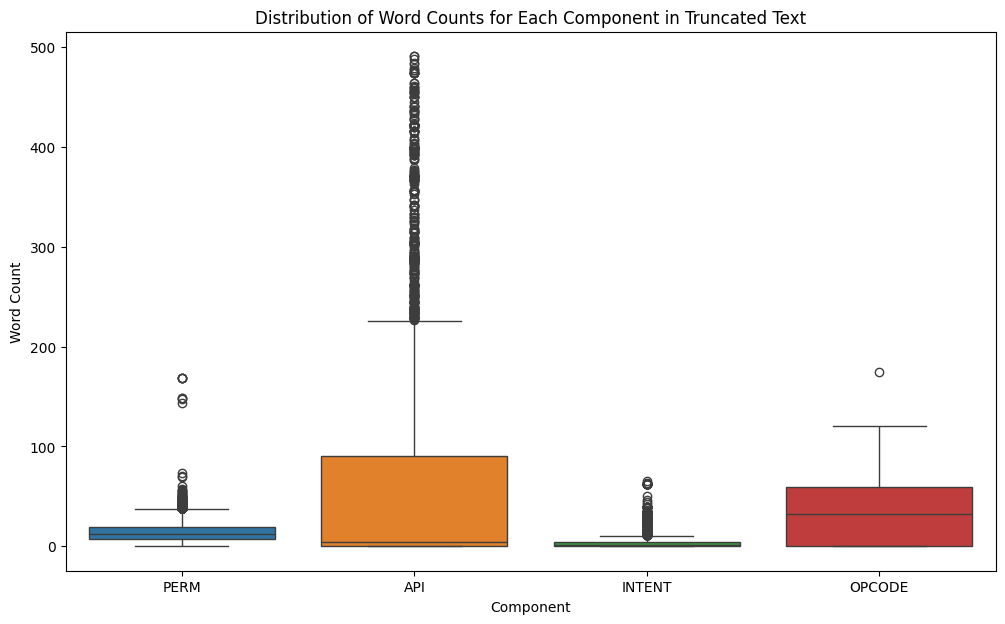


Average word counts for each component:
PERM      15.324048
API       58.286172
INTENT     4.645491
OPCODE    29.994188
dtype: float64


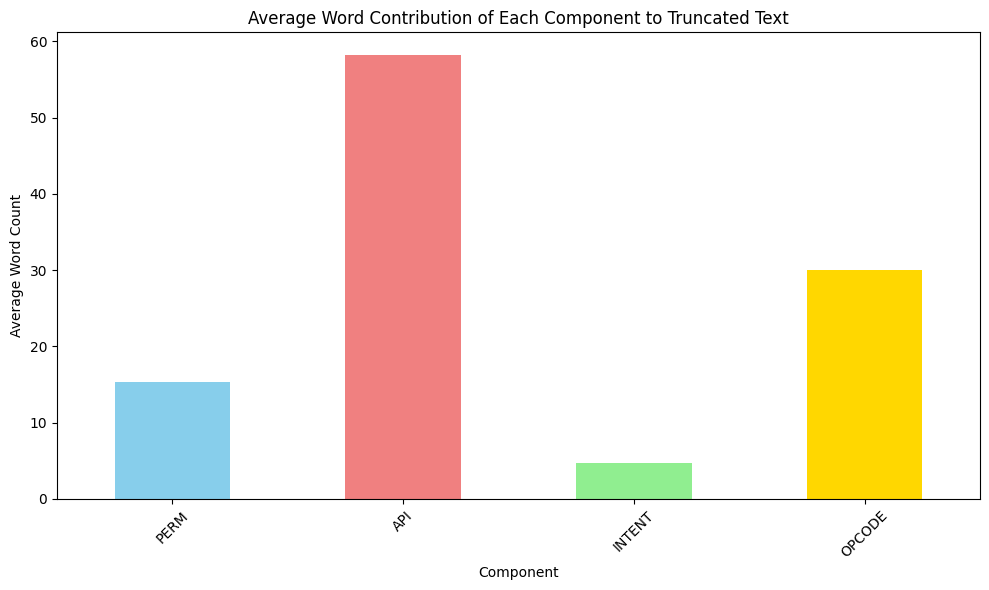

In [53]:
# Box plot to show the distribution of word counts for each component
plt.figure(figsize=(12, 7))
sns.boxplot(data=component_lengths_df)
plt.title('Distribution of Word Counts for Each Component in Truncated Text')
plt.xlabel('Component')
plt.ylabel('Word Count')
plt.grid(axis='y', linestyle='--', alpha=0.0)
plt.show()

# Calculate average word counts for each component
avg_lengths = component_lengths_df.mean()
print("\nAverage word counts for each component:")
print(avg_lengths)

# Bar chart to show the average word contribution of each component
plt.figure(figsize=(10, 6))
avg_lengths.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Average Word Contribution of Each Component to Truncated Text')
plt.xlabel('Component')
plt.ylabel('Average Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:
print("Summary statistics for the DataFrame:")
display(df.describe(include='all'))

Summary statistics for the DataFrame:


,file_name,family,text
count,4990,4990,4990
unique,4990,5,2938
top,4ce2c46fd9d88b2a2552eda6f4afc4c7e19043909fd92a...,SMS,PERM: SEND_SMS RECEIVE INTERNET WAKE_LOCK WRIT...
freq,1,1089,110


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [45]:
path = "/content/final_dataset_transformer.csv"

In [49]:
def truncate_text(text, max_length=512):
    if not isinstance(text, str):
        return ""
    words = text.split()
    if len(words) > max_length:
        return " ".join(words[:max_length])
    return text

df['text'] = df['text'].apply(truncate_text)

print("Text column truncated successfully. Displaying the first entry and its length:")
print("Truncated text example:", df['text'].iloc[0])
print("Length of truncated text (words):", len(df['text'].iloc[0].split()))


Text column truncated successfully. Displaying the first entry and its length:
Truncated text example: PERM: INTERNET ACCESS_NETWORK_STATE CALL_PHONE SEND_SMS WRITE_EXTERNAL_STORAGE VIBRATE READ_PHONE_STATE KILL_BACKGROUND_PROCESSES READ_CONTACTS READ_LOGS WRITE_CONTACTS ACCESS_WIFI_STATE RECEIVE_SMS INSTALL_SHORTCUT GET_TASKS SYSTEM_ALERT_WINDOW MODIFY_PHONE_STATE RESTART_PACKAGES MODIFY_AUDIO_SETTINGS WAKE_LOCK CHANGE_WIFI_STATE RECEIVE_BOOT_COMPLETED UNINSTALL_SHORTCUT API: forceLoad setInternalPageChangeListener executePendingBroadcasts infoForPosition getFragment onProgressUpdate onStopLoading onHiddenChanged setPassword createSDDir getMaxScrollX setBreadCrumbTitle setPageTransformer dumpViewHierarchy setNumber getCallingActivity onMenuItemSelected access$102 onSizeChanged setViewText registerReceiver removeAtRange startActivities valueAt restoreViewState run performDrag takeContentChanged getInfo onAdapterChanged addTab newOnQueryTextListener getString getNotification setFocused 

In [59]:
for i in range(10):
  print((df['text'][i]))

7887
7825
7874
8138
2851
7746
1514
1749
7890
7727


### Install necessary libraries

First, we need to ensure the `transformers` library is installed, which provides the DistilBERT tokenizer. We'll also install `torch` if it's not already present, as it's commonly used with Hugging Face models.

In [ ]:
!pip install transformers torch

### Load DistilBERT Tokenizer and Tokenize 'text' Column

Now we'll load the pre-trained `DistilBertTokenizerFast`. We will then tokenize the `text` column. The `truncation=True` argument will truncate sequences longer than the model's maximum input length (which is 512 for DistilBERT), and `padding='max_length'` will pad shorter sequences to the maximum length. `return_tensors='pt'` ensures the output is in PyTorch tensor format.

In [57]:
from transformers import DistilBertTokenizerFast
import torch

tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Tokenize the 'text' column
encodings = tokenizer(list(df['text'].values), truncation=True, padding='max_length', max_length=512, return_tensors='pt')

print("Tokenization complete. Here's an example of the input IDs for the first entry:")
print(encodings['input_ids'][0])
print("\nAnd its attention mask:")
print(encodings['attention_mask'][0])
print("\nShape of input_ids:", encodings['input_ids'].shape)
print("Shape of attention_mask:", encodings['attention_mask'].shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization complete. Here's an example of the input IDs for the first entry:
tensor([  101,  2566,  2213,  1024,  4274,  3229,  1035,  2897,  1035,  2110,
         2655,  1035,  3042,  4604,  1035, 22434,  4339,  1035,  6327,  1035,
         5527,  6819, 22008,  3191,  1035,  3042,  1035,  2110,  3102,  1035,
         4281,  1035,  6194,  3191,  1035, 10402,  3191,  1035, 15664,  4339,
         1035, 10402,  3229,  1035, 15536,  8873,  1035,  2110,  4374,  1035,
        22434, 16500,  1035,  2460, 12690,  2131,  1035,  8518,  2291,  1035,
         9499,  1035,  3332, 19933,  1035,  3042,  1035,  2110, 23818,  1035,
        14555, 19933,  1035,  5746,  1035, 10906,  5256,  1035,  5843,  2689,
         1035, 15536,  8873,  1035,  2110,  4374,  1035,  9573,  1035,  2949,
         4895,  7076,  9080,  2140,  1035,  2460, 12690, 17928,  1024,  2486,
        11066,  2275, 18447, 11795,  2389, 13704, 22305, 29282,  6528,  2121,
        15389, 11837,  4667, 12618,  4215, 10526,  2015, 18558,